# Skin Lesion Classification with CNNs
### Domain: Computer Vision | Framework: PyTorch

---

## 🌍 Problem Description

Skin cancer is one of the most common cancers worldwide. Early detection dramatically improves survival rates, but dermatologist access is limited in many regions. This project builds a **multi-class skin lesion classifier** that can distinguish between 7 types of skin conditions using dermoscopy images.

**Real-world challenges we tackle:**
- ⚠️ **Severe class imbalance** (some lesion types are 50x rarer than others)
- 📦 **Limited labeled medical data**
- 🧠 **Overfitting** on small datasets

We use **Transfer Learning** with EfficientNet-B0 and address class imbalance using **weighted loss** and **data augmentation**.

---

## 📦 Dataset

**HAM10000** (Human Against Machine with 10000 training images)  
- Source: [Kaggle - Skin Cancer MNIST: HAM10000](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)
- 10,015 dermoscopic images
- 7 classes: Melanoma, Melanocytic nevi, Basal cell carcinoma, Actinic keratoses, Benign keratosis, Dermatofibroma, Vascular lesions

---

## 🚀 How to Run This Project

```bash
# 1. Install dependencies
pip install torch torchvision timm pandas numpy matplotlib scikit-learn seaborn tqdm

# 2. Download the dataset from Kaggle
kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
unzip skin-cancer-mnist-ham10000.zip -d ./data/

# 3. Run the notebook top-to-bottom
jupyter notebook project1_skin_lesion_classification.ipynb
```



In [2]:
!pip install torch torchvision timm pandas numpy matplotlib scikit-learn seaborn tqdm


In [3]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip skin-cancer-mnist-ham10000.zip -d ./data/

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100%|███████████████████████████████████████| 5.20G/5.20G [00:24<00:00, 232MB/s]

Archive:  skin-cancer-mnist-ham10000.zip
  inflating: ./data/HAM10000_images_part_1/ISIC_0024306.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024307.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024308.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024309.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024310.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024311.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024312.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024313.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024314.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024315.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024316.jpg  
  inflating: ./data/HAM10000_images_part_1/ISIC_0024317.jpg  
  inflating: ./data/HAM100

In [4]:

# IMPORTS & SETUP
# We use timm (PyTorch Image Models) for easy access to EfficientNet


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility — always set seeds when you want consistent results
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 📊 Step 1: Data Loading & Exploration

Before building anything, let's understand our data. This step reveals the **class imbalance problem** we need to handle.

In [5]:

# DATA LOADING
# The HAM10000 dataset comes with a CSV metadata file
# and two folders of images (part 1 and part 2)


DATA_DIR = Path('./data')  # adjust this to your data path

# Load metadata
df = pd.read_csv(DATA_DIR / 'HAM10000_metadata.csv')

# Map short codes to readable class names
label_map = {
    'mel':   'Melanoma',
    'nv':    'Melanocytic nevi',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'bkl':   'Benign keratosis',
    'df':    'Dermatofibroma',
    'vasc':  'Vascular lesions'
}

df['label_name'] = df['dx'].map(label_map)
df['label']      = pd.Categorical(df['dx']).codes  # numeric class index

NUM_CLASSES = df['label'].nunique()
CLASS_NAMES = list(label_map.values())

print(f'Total images : {len(df)}')
print(f'Num classes  : {NUM_CLASSES}')
print('\nClass distribution:')
print(df['label_name'].value_counts())

Total images : 10015
Num classes  : 7

Class distribution:
label_name
Melanocytic nevi        6705
Melanoma                1113
Benign keratosis        1099
Basal cell carcinoma     514
Actinic keratoses        327
Vascular lesions         142
Dermatofibroma           115
Name: count, dtype: int64


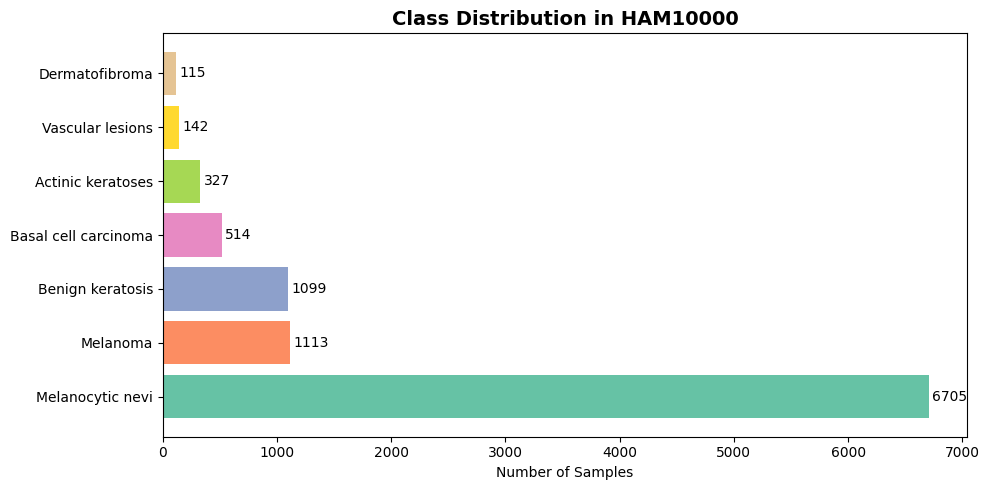


⚠️  Notice the severe imbalance — nevi has ~6700 samples while vasc has only ~142!


In [6]:

# VISUALIZE CLASS IMBALANCE
# This plot makes the imbalance very obvious —
# 'Melanocytic nevi' dominates and some classes
# have only ~100 samples. We MUST handle this.


fig, ax = plt.subplots(figsize=(10, 5))
counts = df['label_name'].value_counts()
bars = ax.barh(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))

for bar, val in zip(bars, counts.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10)

ax.set_title('Class Distribution in HAM10000', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('\n⚠️  Notice the severe imbalance — nevi has ~6700 samples while vasc has only ~142!')

Images found: 10015


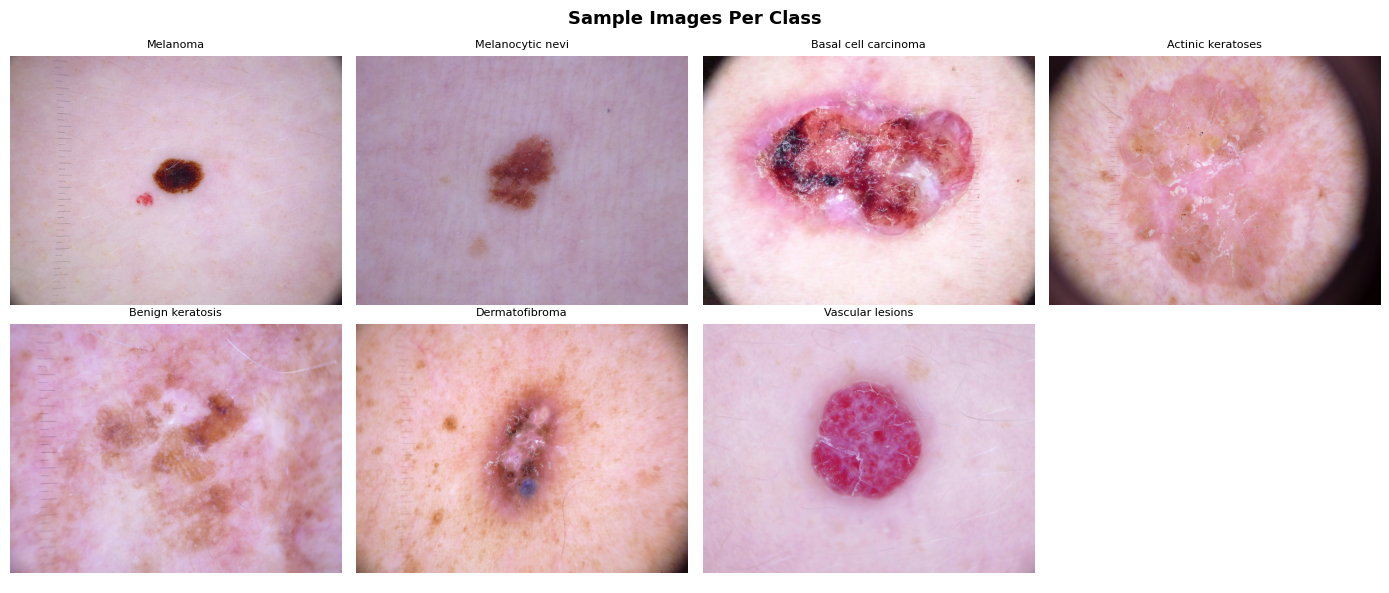

In [7]:

# BUILD IMAGE PATH LOOKUP
# Images are split across two folders, so we
# create a dict {image_id -> full_path}


all_image_paths = {}
for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    folder_path = DATA_DIR / folder
    if folder_path.exists():
        for img_path in folder_path.glob('*.jpg'):
            all_image_paths[img_path.stem] = str(img_path)

df['image_path'] = df['image_id'].map(all_image_paths)
df = df.dropna(subset=['image_path'])  # drop rows with missing images

print(f'Images found: {len(df)}')

# Visualize a few samples per class
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, (cls, name) in enumerate(label_map.items()):
    sample = df[df['dx'] == cls].iloc[0]
    img = Image.open(sample['image_path'])
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=8)
    axes[i].axis('off')
axes[-1].axis('off')  # hide the 8th subplot
plt.suptitle('Sample Images Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## 🔧 Step 2: Data Preprocessing & Augmentation

For medical images, aggressive augmentation helps the model generalize without memorizing patient-specific artifacts. We use:
- **Horizontal/vertical flips** (lesions are orientation-invariant)
- **Color jitter** (lighting varies across dermatoscopes)
- **Random rotation and cropping**
- **Normalization** using ImageNet statistics (since we're using pretrained weights)

In [8]:

# TRAIN / VAL / TEST SPLIT
# We stratify the split to keep class proportions
# consistent across all three sets


train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')


# TRANSFORMS
# EfficientNet-B0 expects 224×224 inputs.
# Training gets augmentation; val/test do not.


IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

Train: 8012 | Val: 1001 | Test: 1002


In [9]:

# CUSTOM DATASET CLASS
# PyTorch Datasets are very flexible — you just
# need __len__ and __getitem__


class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label



# WEIGHTED SAMPLER — key trick for imbalance!
# Instead of oversampling manually, we tell
# PyTorch to sample rare classes more often
# during training.


class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_df['label'].values]

sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(train_df),
    replacement=True
)

# Build datasets & dataloaders
train_ds = SkinLesionDataset(train_df, train_transforms)
val_ds   = SkinLesionDataset(val_df,   val_test_transforms)
test_ds  = SkinLesionDataset(test_df,  val_test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 251 | Val: 32 | Test: 32


## 🏗️ Step 3: Model Architecture

We use **EfficientNet-B0** — it achieves excellent accuracy with far fewer parameters than ResNet or VGG. The strategy is:

1. Load pretrained weights (trained on ImageNet)
2. **Freeze all layers** initially and only train the new classification head
3. Later, **unfreeze** the last few blocks for fine-tuning

This is called **progressive fine-tuning** and significantly reduces overfitting on small datasets.

In [10]:

# MODEL BUILDING
# timm makes loading pretrained models very easy.
# We replace the final classifier head to match
# our 7-class problem.


def build_model(num_classes, pretrained=True):
    # EfficientNet-B0: ~5.3M params, great for limited GPU
    model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=num_classes)

    # Freeze all backbone layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze only the final classification head
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

model = build_model(NUM_CLASSES)
model = model.to(DEVICE)

# Count trainable vs frozen parameters — useful for debugging
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total params     : 4,016,515
Trainable params : 8,967  (0.2%)


## 🎯 Step 4: Training

We train in **two phases**:
- **Phase 1**: Only the head is trainable → fast convergence, prevents destroying pretrained features
- **Phase 2**: Unfreeze last few blocks → fine-tune with a lower learning rate

In [11]:

# LOSS & OPTIMIZER
# CrossEntropyLoss with class weights handles
# imbalance at the loss level too — double protection!


class_weight_tensor = torch.FloatTensor(class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=1e-3, weight_decay=1e-4)

# Cosine annealing keeps the LR schedule smooth
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [12]:

# TRAINING LOOP
# We track train/val loss and accuracy per epoch
# and save the best model checkpoint


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def train(model, train_loader, val_loader, criterion, optimizer, scheduler,
          n_epochs, device, checkpoint_path='best_model.pt'):

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Save best model by validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)
            saved_marker = ' ✅ saved'
        else:
            saved_marker = ''

        print(f'Epoch {epoch:02d}/{n_epochs} | '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{saved_marker}')

    return history


# ── PHASE 1: Train head only (10 epochs) ──
print('=== Phase 1: Training classification head ===')
history_phase1 = train(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       n_epochs=10, device=DEVICE)

=== Phase 1: Training classification head ===


Epoch 01/10 | Train Loss: 2.0393  Acc: 0.2571 | Val Loss: 3.0365  Acc: 0.0919 ✅ saved


Epoch 02/10 | Train Loss: 1.2541  Acc: 0.3778 | Val Loss: 2.3695  Acc: 0.1409 ✅ saved


Epoch 03/10 | Train Loss: 1.0715  Acc: 0.4265 | Val Loss: 2.0948  Acc: 0.1788 ✅ saved


Epoch 04/10 | Train Loss: 0.9911  Acc: 0.4518 | Val Loss: 2.0943  Acc: 0.1808 ✅ saved


...

Epoch 06/10 | Train Loss: 0.8482  Acc: 0.4832 | Val Loss: 1.8380  Acc: 0.2288 ✅ saved


Epoch 07/10 | Train Loss: 0.8182  Acc: 0.4906 | Val Loss: 1.9015  Acc: 0.2178


Epoch 08/10 | Train Loss: 0.7800  Acc: 0.5080 | Val Loss: 1.8024  Acc: 0.2507 ✅ saved


Epoch 09/10 | Train Loss: 0.7721  Acc: 0.5100 | Val Loss: 1.8456  Acc: 0.2378


Epoch 10/10 | Train Loss: 0.7662  Acc: 0.5070 | Val Loss: 1.8102  Acc: 0.2358


In [13]:

# PHASE 2: Fine-tune last 2 blocks + head
# We unfreeze deeper layers and train with a
# MUCH lower LR to avoid destroying features


print('=== Phase 2: Fine-tuning deeper layers ===')

# Unfreeze last 2 EfficientNet blocks
for name, param in model.named_parameters():
    if 'blocks.5' in name or 'blocks.6' in name or 'classifier' in name:
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreeze: {trainable_params:,}')

# Lower LR for fine-tuning — very important!
optimizer_ft = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=1e-4, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=10)

history_phase2 = train(model, train_loader, val_loader, criterion, optimizer_ft, scheduler_ft,
                       n_epochs=10, device=DEVICE, checkpoint_path='best_model_ft.pt')

=== Phase 2: Fine-tuning deeper layers ===
Trainable params after unfreeze: 2,752,547


Epoch 01/10 | Train Loss: 0.5647  Acc: 0.5855 | Val Loss: 1.4201  Acc: 0.3187 ✅ saved


Epoch 02/10 | Train Loss: 0.3612  Acc: 0.6796 | Val Loss: 1.3213  Acc: 0.3676 ✅ saved


Epoch 03/10 | Train Loss: 0.2619  Acc: 0.7333 | Val Loss: 1.0558  Acc: 0.4755 ✅ saved


Epoch 04/10 | Train Loss: 0.2195  Acc: 0.7631 | Val Loss: 1.0359  Acc: 0.4765 ✅ saved


...

Epoch 06/10 | Train Loss: 0.1764  Acc: 0.7879 | Val Loss: 0.9782  Acc: 0.5095


Epoch 07/10 | Train Loss: 0.1489  Acc: 0.8153 | Val Loss: 0.8778  Acc: 0.5265 ✅ saved


Epoch 08/10 | Train Loss: 0.1317  Acc: 0.8236 | Val Loss: 0.9069  Acc: 0.5495 ✅ saved


Epoch 09/10 | Train Loss: 0.1315  Acc: 0.8208 | Val Loss: 0.8529  Acc: 0.5634 ✅ saved


Epoch 10/10 | Train Loss: 0.1397  Acc: 0.8155 | Val Loss: 0.8710  Acc: 0.5375


## 📈 Step 5: Training Visualization

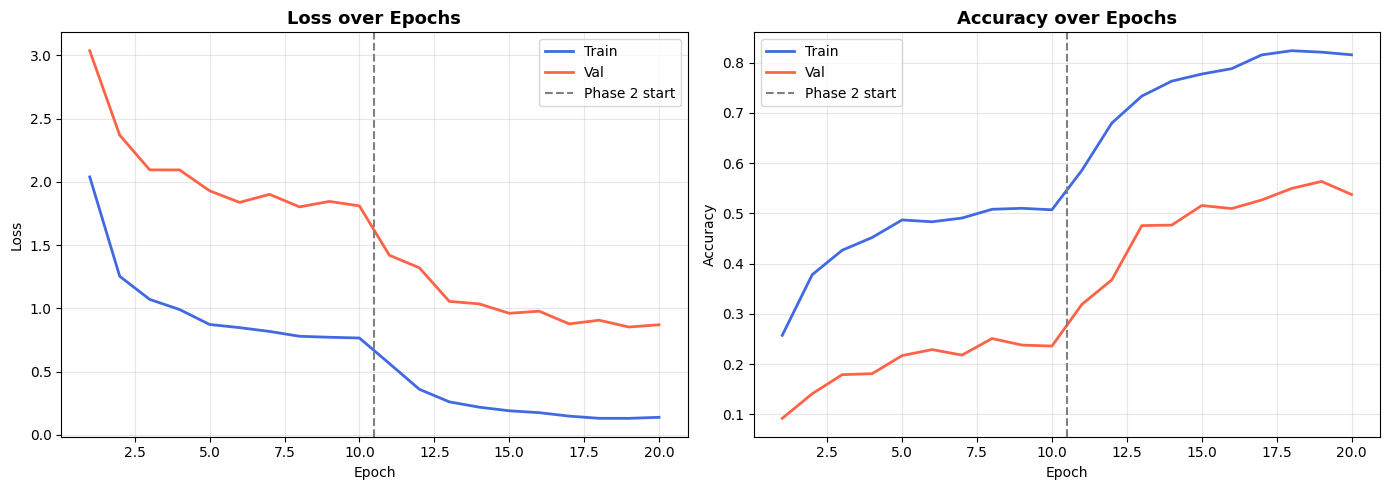

In [14]:
# Merge both phases for plotting
combined_train_loss = history_phase1['train_loss'] + history_phase2['train_loss']
combined_val_loss   = history_phase1['val_loss']   + history_phase2['val_loss']
combined_train_acc  = history_phase1['train_acc']  + history_phase2['train_acc']
combined_val_acc    = history_phase1['val_acc']    + history_phase2['val_acc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(combined_train_loss) + 1)

# Loss plot
axes[0].plot(epochs, combined_train_loss, label='Train', color='royalblue', linewidth=2)
axes[0].plot(epochs, combined_val_loss,   label='Val',   color='tomato',    linewidth=2)
axes[0].axvline(x=10.5, color='gray', linestyle='--', label='Phase 2 start')
axes[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, combined_train_acc, label='Train', color='royalblue', linewidth=2)
axes[1].plot(epochs, combined_val_acc,   label='Val',   color='tomato',    linewidth=2)
axes[1].axvline(x=10.5, color='gray', linestyle='--', label='Phase 2 start')
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 🧪 Step 6: Evaluation on Test Set

We evaluate using:
- **Per-class F1 score** (essential for imbalanced datasets — accuracy alone is misleading)
- **Confusion matrix**

In [15]:
# Load the best saved checkpoint
model.load_state_dict(torch.load('best_model_ft.pt', map_location=DEVICE))

_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)
print(f'Test Accuracy: {test_acc:.4f}\n')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

Test Accuracy: 0.5689

                      precision    recall  f1-score   support

            Melanoma       0.33      0.66      0.44        32
    Melanocytic nevi       0.49      0.75      0.59        52
Basal cell carcinoma       0.38      0.67      0.49       110
   Actinic keratoses       0.48      1.00      0.65        11
    Benign keratosis       0.29      0.71      0.41       112
      Dermatofibroma       0.99      0.50      0.67       671
    Vascular lesions       0.29      0.71      0.42        14

            accuracy                           0.57      1002
           macro avg       0.47      0.71      0.52      1002
        weighted avg       0.78      0.57      0.60      1002



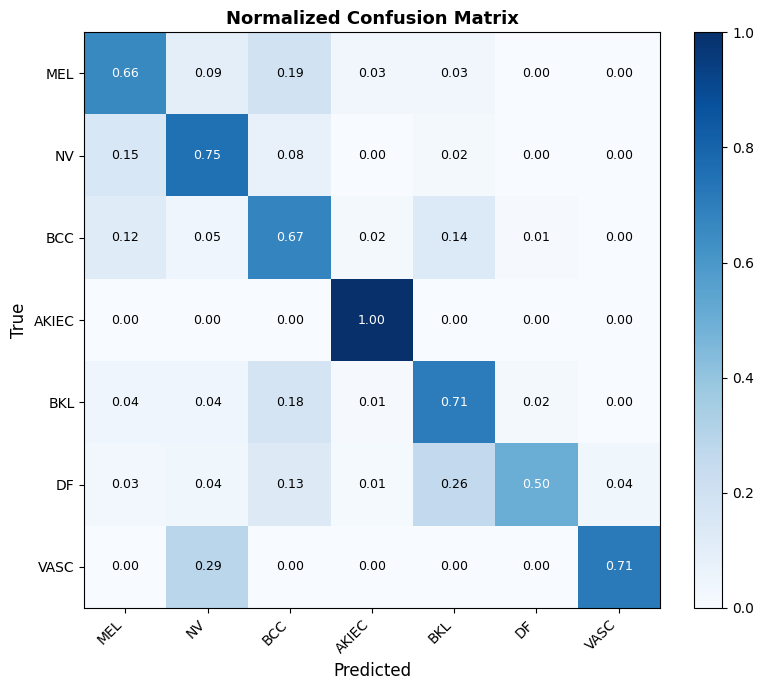

In [16]:

# CONFUSION MATRIX
# Normalized by true labels so we see *recall*
# per class — especially useful when classes
# are imbalanced


short_names = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
cm = confusion_matrix(test_labels, test_preds, normalize='true')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticklabels(short_names)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = 'white' if cm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 🔮 Improvements & Future Work

| Idea | Expected Benefit |
|------|------------------|
| **Test-Time Augmentation (TTA)** | +1-2% accuracy by averaging predictions over augmented views |
| **Mixup / CutMix augmentation** | Better generalization, especially for minority classes |
| **Larger backbone (EfficientNet-B4)** | More capacity, useful if you have more GPU memory |
| **Grad-CAM heatmaps** | Explainability — see where the model looks |
| **Ensemble of 3 models** | Reliably +2-3% over any single model |
| **Semi-supervised learning** | Leverage unlabeled dermoscopy images from the web |